In [187]:
import panel as pn
import numpy as np
import pandas as pd
import hvplot.pandas
import warnings
import datetime as dt
import seaborn as sb
import matplotlib.pyplot as plt

### This is a data set file for Social Media Metrics of differents Platform
##### We have differents values such as Followers, Likes, Shares, Comments and EngagementRate

In [188]:
df = pd.read_csv("social_media_metrics_400.csv")

In [189]:
df.dtypes

Date               object
Platform           object
Followers           int64
Likes               int64
Shares              int64
Comments            int64
EngagementRate    float64
dtype: object

###  Converting Date
##### Year, Month and Day

In [190]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month Name'] = df['Date'].dt.month_name()
df['Day Name'] = df['Date'].dt.day_name()

df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df['Week'] = df['Date'].dt.isocalendar().week

In [191]:
df['Year'] = df['Year'].astype("str")

In [192]:
unique_year = df['Year'].unique()

In [193]:
df.columns

Index(['Date', 'Platform', 'Followers', 'Likes', 'Shares', 'Comments',
       'EngagementRate', 'Year', 'Month Name', 'Day Name', 'Month', 'Day',
       'Week'],
      dtype='object')

In [194]:
df.describe()

,Followers,Likes,Shares,Comments,EngagementRate,Month,Day,Week
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2900.178333,274.061667,51.027500,27.420000,0.151317,6.052500,15.610000,24.417500
std,1205.675184,129.854719,27.826402,12.682572,0.058765,3.633971,8.866985,15.787524
min,801.000000,50.000000,5.000000,5.000000,0.050000,1.000000,1.000000,1.000000
25%,1853.000000,162.000000,26.000000,17.000000,0.100000,3.000000,8.000000,10.000000
50%,2902.000000,270.000000,51.000000,27.000000,0.150000,6.000000,16.000000,24.000000
75%,3955.750000,392.000000,75.000000,38.000000,0.200000,9.000000,23.000000,38.000000
max,4995.000000,499.000000,99.000000,49.000000,0.250000,12.000000,31.000000,52.000000


In [195]:
df.dtypes

Date              datetime64[ns]
Platform                  object
Followers                  int64
Likes                      int64
Shares                     int64
Comments                   int64
EngagementRate           float64
Year                      object
Month Name                object
Day Name                  object
Month                      int64
Day                        int64
Week                      UInt32
dtype: object

In [196]:
df.shape

(1200, 13)

In [197]:
df.isna().sum()

Date              0
Platform          0
Followers         0
Likes             0
Shares            0
Comments          0
EngagementRate    0
Year              0
Month Name        0
Day Name          0
Month             0
Day               0
Week              0
dtype: int64

In [198]:
df.head()

,Date,Platform,Followers,Likes,Shares,Comments,EngagementRate,Year,Month Name,Day Name,Month,Day,Week
0,2025-01-01,Facebook,1660,320,76,25,0.08,2025,January,Wednesday,1,1,1
1,2025-01-01,Twitter,1266,264,79,15,0.22,2025,January,Wednesday,1,1,1
2,2025-01-01,Instagram,3971,409,28,7,0.05,2025,January,Wednesday,1,1,1
3,2025-01-02,Facebook,1569,393,34,42,0.05,2025,January,Thursday,1,2,1
4,2025-01-02,Twitter,1984,363,26,48,0.05,2025,January,Thursday,1,2,1


In [199]:
number_details = ['Followers', 'Likes', 'Shares', 'Comments', 'EngagementRate', 'Month']

### Differents Social Media Platform
##### Maximum Content Values by Followers, Likes, Shares, Comments and Engagement Rate

In [200]:
segment_hs_code_description = pd.pivot_table(df, values=number_details, index='Platform',
                          aggfunc=max)

segment_hs_code_description = segment_hs_code_description.sort_values(by='Followers', ascending=False)
segment_hs_code_description.style.background_gradient(cmap="cubehelix")

,Comments,EngagementRate,Followers,Likes,Month,Shares
Platform,,,,,,
Facebook,49,0.250000,4995,497,12,99
Twitter,49,0.250000,4993,499,12,99
Instagram,49,0.250000,4988,499,12,99


### Differents Social Media Platform
##### Minimum Content Values by Followers, Likes, Shares, Comments and Engagement Rate

In [201]:
segment_hs_code_description = pd.pivot_table(df, values=number_details, index='Platform',
                          aggfunc=min)

segment_hs_code_description = segment_hs_code_description.sort_values(by='Followers', ascending=False)
segment_hs_code_description.style.background_gradient(cmap="cubehelix")

,Comments,EngagementRate,Followers,Likes,Month,Shares
Platform,,,,,,
Instagram,5,0.050000,824,51,1,5
Twitter,5,0.050000,809,50,1,5
Facebook,5,0.050000,801,50,1,5


### Differents Year
##### Maximum Content Values by Followers, Likes, Shares, Comments and Engagement Rate

In [202]:
segment_hs_code_description = pd.pivot_table(df, values=number_details, index='Year',
                          aggfunc=max)

segment_hs_code_description = segment_hs_code_description.sort_values(by='Year', ascending=True)
segment_hs_code_description.style.background_gradient(cmap="cubehelix")

,Comments,EngagementRate,Followers,Likes,Month,Shares
Year,,,,,,
2025,49,0.250000,4995,499,12,99
2026,49,0.250000,4974,492,2,99


### Differents Year
##### Minimum Content Values by Followers, Likes, Shares, Comments and Engagement Rate

In [203]:
segment_hs_code_description = pd.pivot_table(df, values=number_details, index='Year',
                          aggfunc=min)

segment_hs_code_description = segment_hs_code_description.sort_values(by='Year', ascending=True)
segment_hs_code_description.style.background_gradient(cmap="cubehelix")

,Comments,EngagementRate,Followers,Likes,Month,Shares
Year,,,,,,
2025,5,0.050000,801,50,1,5
2026,5,0.050000,828,50,1,7


### Differents Month
##### Maximum Content Values by Followers, Likes, Shares, Comments and Engagement Rate

In [204]:
segment_hs_code_description = pd.pivot_table(df, values=number_details, index='Month Name',
                          aggfunc=max)

segment_hs_code_description = segment_hs_code_description.sort_values(by='Month', ascending=True)
segment_hs_code_description.style.background_gradient(cmap="cubehelix")

,Comments,EngagementRate,Followers,Likes,Month,Shares
Month Name,,,,,,
January,49,0.250000,4897,495,1,99
February,49,0.250000,4988,496,2,99
March,49,0.250000,4993,495,3,98
April,48,0.250000,4869,498,4,98
May,49,0.250000,4938,499,5,97
June,49,0.250000,4983,499,6,99
July,49,0.250000,4809,492,7,96
August,49,0.240000,4917,490,8,99
September,49,0.250000,4995,477,9,97


### Differents Month
##### Minimum Content Values by Followers, Likes, Shares, Comments and Engagement Rate

In [205]:
segment_hs_code_description = pd.pivot_table(df, values=number_details, index='Month Name',
                          aggfunc=min)

segment_hs_code_description = segment_hs_code_description.sort_values(by='Month', ascending=True)
segment_hs_code_description.style.background_gradient(cmap="cubehelix")

,Comments,EngagementRate,Followers,Likes,Month,Shares
Month Name,,,,,,
January,5,0.050000,828,50,1,5
February,5,0.050000,809,50,2,5
March,5,0.050000,846,51,3,5
April,7,0.050000,801,56,4,6
May,6,0.050000,809,56,5,5
June,6,0.050000,962,52,6,5
July,6,0.060000,867,50,7,6
August,6,0.050000,824,53,8,5
September,5,0.050000,842,51,9,5


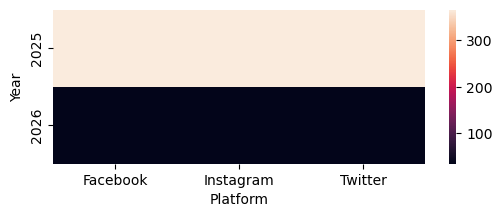

In [206]:
plt.figure(figsize = [6, 2])

ct_counts = df.groupby(['Year', 'Platform']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'Year', columns = 'Platform', values = 'count')

sb.heatmap(ct_counts);

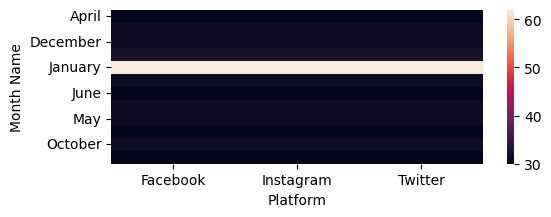

In [207]:
plt.figure(figsize = [6, 2])

ct_counts = df.groupby(['Month Name', 'Platform']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'Month Name', columns = 'Platform', values = 'count')

sb.heatmap(ct_counts);

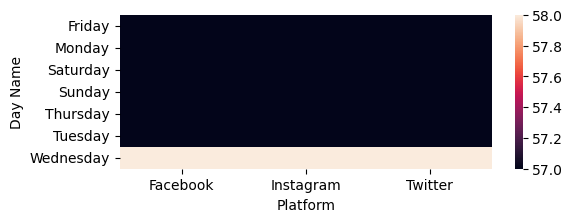

In [208]:
plt.figure(figsize = [6, 2])

ct_counts = df.groupby(['Day Name', 'Platform']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'Day Name', columns = 'Platform', values = 'count')

sb.heatmap(ct_counts);

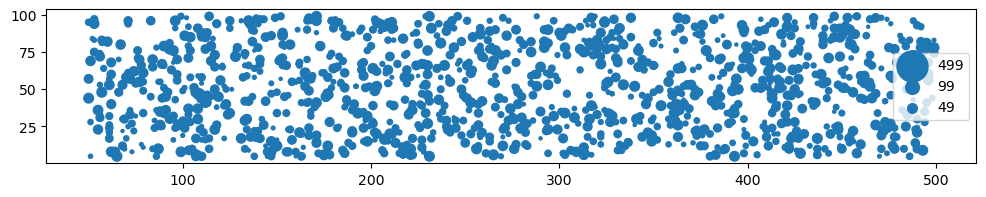

In [209]:
plt.figure(figsize = [12, 2])

plt.scatter(data = df, x = 'Likes', y = 'Shares', s = 'Comments')

max_likes = df['Likes'].max()
max_shares = df['Shares'].max()
max_comments = df['Comments'].max()

# dummy series for adding legend
sizes = [max_likes, max_shares, max_comments]
base_color = sb.color_palette()[0]
legend_obj = []
for s in sizes:
    legend_obj.append(plt.scatter([], [], s = s, color = base_color))
plt.legend(legend_obj, sizes);

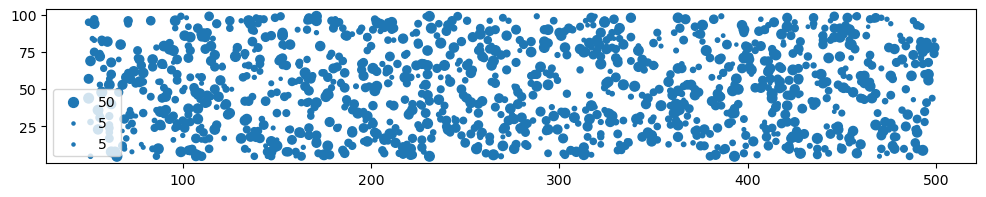

In [210]:
plt.figure(figsize = [12, 2])

plt.scatter(data = df, x = 'Likes', y = 'Shares', s = 'Comments')

min_likes = df['Likes'].min()
min_shares = df['Shares'].min()
min_comments = df['Comments'].min()

# dummy series for adding legend
sizes = [min_likes, min_shares, min_comments]
base_color = sb.color_palette()[0]
legend_obj = []
for s in sizes:
    legend_obj.append(plt.scatter([], [], s = s, color = base_color))
plt.legend(legend_obj, sizes);

### Platform vs Followers by Year
##### From the Plot Box graph below, we can see that in 2026 Twitter and Instagram have the highest Followers and by the way, Facebook had only more followers in 2025

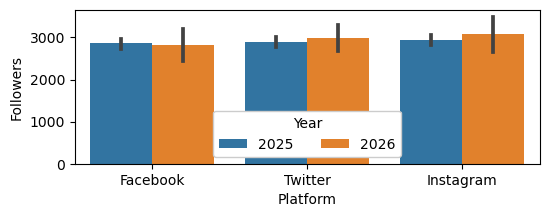

In [211]:
plt.figure(figsize = [6, 2])

ax = sb.barplot(data = df, x = 'Platform', y = 'Followers', hue = 'Year');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Year');

### Platform vs Likes by Year
##### From the Plot Box graph below, we can see that in 2025 Facebook, Twitter and Instagram have the highest Likes

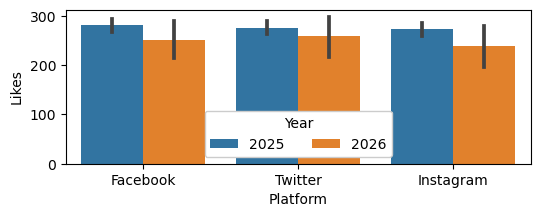

In [212]:
plt.figure(figsize = [6, 2])

ax = sb.barplot(data = df, x = 'Platform', y = 'Likes', hue = 'Year');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Year');

### Platform vs Shares by Year
##### From the Plot Box graph below, we can see that in 2026 Facebook, Twitter and Instagram have the highest Shares

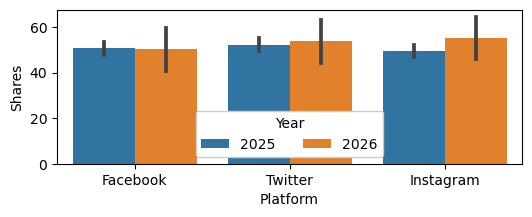

In [213]:
plt.figure(figsize = [6, 2])

ax = sb.barplot(data = df, x = 'Platform', y = 'Shares', hue = 'Year');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Year');

### Platform vs Comments by Year
##### From the Plot Box graph below, we can see that in 2025 Facebook and Twitter more comments. And Instagram in 2026 had more comments

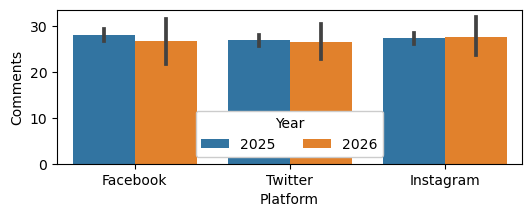

In [214]:
plt.figure(figsize = [6, 2])

ax = sb.barplot(data = df, x = 'Platform', y = 'Comments', hue = 'Year');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Year');

### Year vs Followers by Platform
##### The Plot Box Graph below show that Facebook have the lowest Followers, Twitter and Instagram have the highest Followers in both 2025 and 2026.

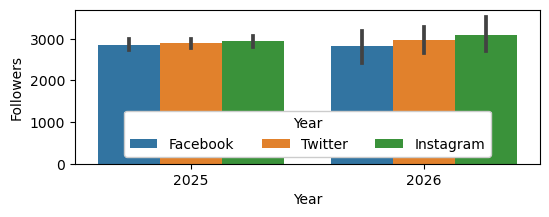

In [215]:
plt.figure(figsize = [6, 2])

ax = sb.barplot(data = df, x = 'Year', y = 'Followers', hue = 'Platform');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Year');

### Year vs Likes by Platform

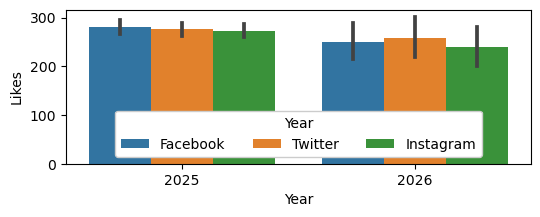

In [216]:
plt.figure(figsize = [6, 2])

ax = sb.barplot(data = df, x = 'Year', y = 'Likes', hue = 'Platform');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Year');

### Year vs Shares by Platform

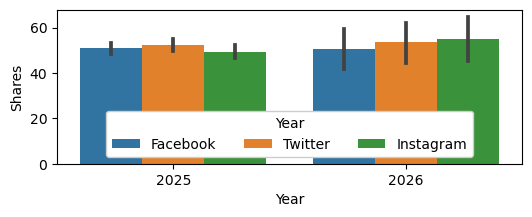

In [217]:
plt.figure(figsize = [6, 2])

ax = sb.barplot(data = df, x = 'Year', y = 'Shares', hue = 'Platform');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Year');

### Year vs Comments by Platform

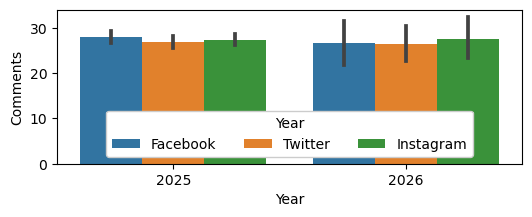

In [218]:
plt.figure(figsize = [6, 2])

ax = sb.barplot(data = df, x = 'Year', y = 'Comments', hue = 'Platform');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Year');

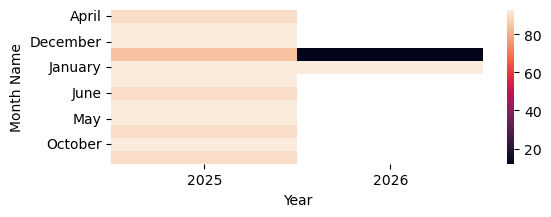

In [219]:
plt.figure(figsize = [6, 2])

ct_counts = df.groupby(['Year', 'Month Name']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'Month Name', columns = 'Year', values = 'count')

sb.heatmap(ct_counts);

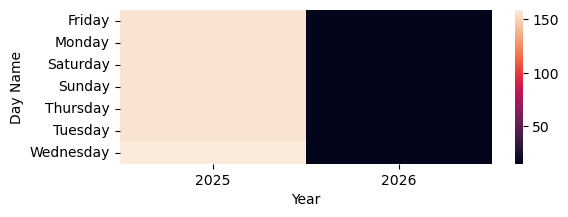

In [220]:
plt.figure(figsize = [6, 2])

ct_counts = df.groupby(['Year', 'Day Name']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'Day Name', columns = 'Year', values = 'count')

sb.heatmap(ct_counts);

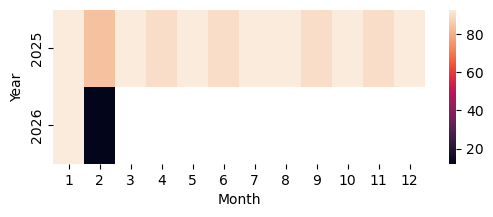

In [221]:
plt.figure(figsize = [6, 2])

ct_counts = df.groupby(['Month', 'Year']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'Year', columns = 'Month', values = 'count')

sb.heatmap(ct_counts);

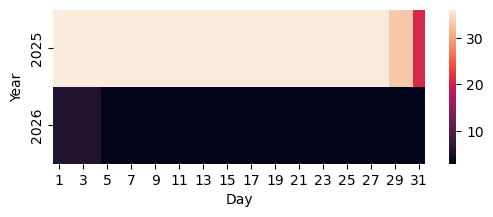

In [222]:
plt.figure(figsize = [6, 2])

ct_counts = df.groupby(['Day', 'Year']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'Year', columns = 'Day', values = 'count')

sb.heatmap(ct_counts);

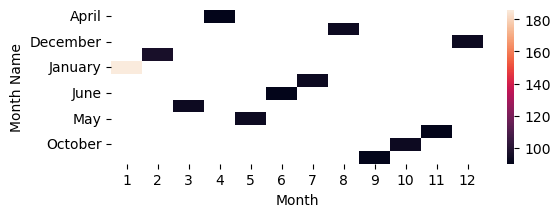

In [223]:
plt.figure(figsize = [6, 2])

ct_counts = df.groupby(['Month', 'Month Name']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'Month Name', columns = 'Month', values = 'count')

sb.heatmap(ct_counts);

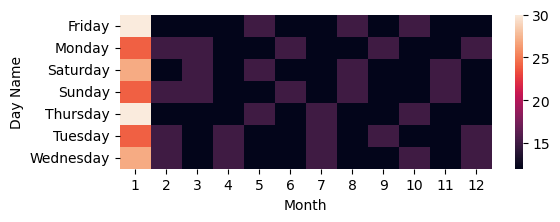

In [224]:
plt.figure(figsize = [6, 2])

ct_counts = df.groupby(['Month', 'Day Name']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'Day Name', columns = 'Month', values = 'count')

sb.heatmap(ct_counts);

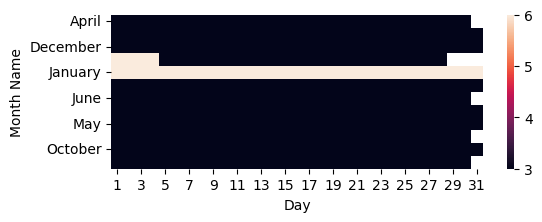

In [225]:
plt.figure(figsize = [6, 2])

ct_counts = df.groupby(['Day', 'Month Name']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'Month Name', columns = 'Day', values = 'count')

sb.heatmap(ct_counts);

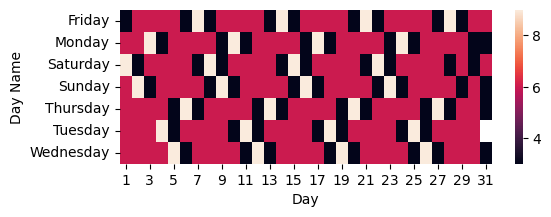

In [226]:
plt.figure(figsize = [6, 2])

ct_counts = df.groupby(['Day', 'Day Name']).size()
ct_counts = ct_counts.reset_index(name = 'count')
ct_counts = ct_counts.pivot(index = 'Day Name', columns = 'Day', values = 'count')

sb.heatmap(ct_counts);

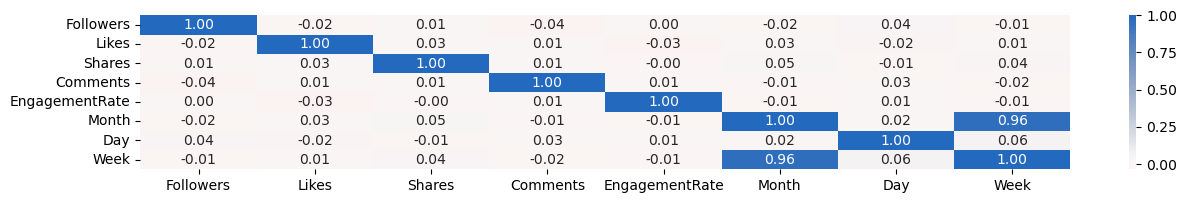

In [227]:
plt.figure(figsize = [15, 2])

sb.heatmap(df.corr(), annot = True, fmt = '.2f', cmap = 'vlag_r', center = 0);

In [228]:
platform = df['Platform'].unique().tolist()

In [229]:
platform

['Facebook', 'Twitter', 'Instagram']

In [230]:
len(platform)

3

In [231]:
from collections import Counter

In [232]:
p = Counter(platform)

In [233]:
p

Counter({'Facebook': 1, 'Twitter': 1, 'Instagram': 1})

In [234]:
p.most_common(1)

[('Facebook', 1)]

In [235]:
month_name = df['Month Name'].unique().tolist()

In [236]:
month_name

['January',
 'February',
 'March',
 'April',
 'May',
 'June',
 'July',
 'August',
 'September',
 'October',
 'November',
 'December']

In [237]:
len(month_name)

12

In [238]:
from collections import Counter

In [239]:
m = Counter(month_name)

In [240]:
m

Counter({'January': 1,
         'February': 1,
         'March': 1,
         'April': 1,
         'May': 1,
         'June': 1,
         'July': 1,
         'August': 1,
         'September': 1,
         'October': 1,
         'November': 1,
         'December': 1})

In [241]:
m.most_common(1)

[('January', 1)]

In [242]:
day_name = df['Day Name'].unique().tolist()

In [243]:
len(day_name)

7

In [244]:
from collections import Counter

In [245]:
c = Counter(day_name)

In [246]:
c

Counter({'Wednesday': 1,
         'Thursday': 1,
         'Friday': 1,
         'Saturday': 1,
         'Sunday': 1,
         'Monday': 1,
         'Tuesday': 1})

In [247]:
c.most_common(1)

[('Wednesday', 1)]

In [248]:
df['Month Name'][:5]

0    January
1    January
2    January
3    January
4    January
Name: Month Name, dtype: object

In [249]:
df['Day Name'][:5]

0    Wednesday
1    Wednesday
2    Wednesday
3     Thursday
4     Thursday
Name: Day Name, dtype: object

In [250]:
type(df)

pandas.core.frame.DataFrame

In [251]:
df['Platform'][:5]

0     Facebook
1      Twitter
2    Instagram
3     Facebook
4      Twitter
Name: Platform, dtype: object

In [252]:
new_columns = ['Date', 'Platform', 'Followers', 'Shares', 'Likes', 'Comments', 'EngagementRate', 'Year', 'Month Name', 'Day Name']

In [253]:
df_rename = pd.read_csv("social_media.csv", names=new_columns)

In [254]:
df_rename = df_rename.rename(columns={"Date":"Date Validée", "Platform":"Platformes", "Shares":"Partager", "Likes": "J'aime","Comments":"Commentaires", 
                                      "EngagementRate":"Taux d'Engagement", "Year":"Année", "Month Name": "Mois","Day Name":"Jour"})

In [255]:
df_rename.head()

,Date Validée,Platformes,Followers,Partager,J'aime,Commentaires,Taux d'Engagement,Année,Mois,Jour
0,Date,Platform,Followers,Likes,Shares,Comments,EngagementRate,NaN,NaN,NaN
1,2025-01-01,Facebook,1660,320,76,25,0.08,NaN,NaN,NaN
2,2025-01-01,Twitter,1266,264,79,15,0.22,NaN,NaN,NaN
3,2025-01-01,Instagram,3971,409,28,7,0.05,NaN,NaN,NaN
4,2025-01-02,Facebook,1569,393,34,42,0.05,NaN,NaN,NaN


In [256]:
df_rename.tail()

,Date Validée,Platformes,Followers,Partager,J'aime,Commentaires,Taux d'Engagement,Année,Mois,Jour
1196,2026-02-03,Twitter,1783,401,65,36,0.25,NaN,NaN,NaN
1197,2026-02-03,Instagram,2707,290,17,5,0.06,NaN,NaN,NaN
1198,2026-02-04,Facebook,4974,285,82,33,0.15,NaN,NaN,NaN
1199,2026-02-04,Twitter,3349,464,68,29,0.08,NaN,NaN,NaN
1200,2026-02-04,Instagram,4439,143,97,24,0.13,NaN,NaN,NaN


In [257]:
df_rename.dtypes

Date Validée          object
Platformes            object
Followers             object
Partager              object
J'aime                object
Commentaires          object
Taux d'Engagement     object
Année                float64
Mois                 float64
Jour                 float64
dtype: object

In [258]:
df_rank = pd.read_csv("social_media_metrics_400.csv")

In [259]:
df_rank['Date'] = pd.to_datetime(df_rank['Date'])
df_rank['Year'] = df_rank['Date'].dt.year
df_rank['Month Name'] = df_rank['Date'].dt.month_name()
df_rank['Day Name'] = df_rank['Date'].dt.day_name()

df_rank['Month'] = df_rank['Date'].dt.month
df_rank['Day'] = df_rank['Date'].dt.day

df_rank['Week'] = df_rank['Date'].dt.isocalendar().week

In [260]:
df_rank = df_rank[['Platform', 'Year', 'Followers', 'Likes', 'Shares', 'Comments',
       'EngagementRate']]

In [261]:
df_rank['Rank Platform'] = df_rank['Platform'].rank(ascending=1)

In [262]:
df_rank['Rank Followers'] = df_rank['Followers'].rank(ascending=1)

In [263]:
df_rank['Rank Likes'] = df_rank['Likes'].rank(ascending=1)

In [264]:
df_rank['Rank Shares'] = df_rank['Shares'].rank(ascending=1)

In [265]:
df_rank['Rank Comments'] = df_rank['Comments'].rank(ascending=1)

In [266]:
df_rank['Rank Engagement Rate'] = df_rank['EngagementRate'].rank(ascending=1)

In [267]:
df_rank.head()

,Platform,Year,Followers,Likes,Shares,Comments,EngagementRate,Rank Platform,Rank Followers,Rank Likes,Rank Shares,Rank Comments,Rank Engagement Rate
0,Facebook,2025,1660,320,76,25,0.08,200.5,237.0,720.0,909.5,527.0,191.5
1,Twitter,2025,1266,264,79,15,0.22,1000.5,130.0,585.0,950.0,259.5,1011.0
2,Instagram,2025,3971,409,28,7,0.05,600.5,905.0,947.0,326.5,55.0,19.0
3,Facebook,2025,1569,393,34,42,0.05,200.5,210.5,905.5,401.0,1001.0,19.0
4,Twitter,2025,1984,363,26,48,0.05,1000.5,342.5,826.5,299.5,1152.5,19.0


In [268]:
df_rank.tail()

,Platform,Year,Followers,Likes,Shares,Comments,EngagementRate,Rank Platform,Rank Followers,Rank Likes,Rank Shares,Rank Comments,Rank Engagement Rate
1195,Twitter,2026,1783,401,65,36,0.25,1000.5,273.5,930.0,775.5,843.5,1186.5
1196,Instagram,2026,2707,290,17,5,0.06,600.5,546.0,649.0,169.0,9.0,68.0
1197,Facebook,2026,4974,285,82,33,0.15,200.5,1192.0,639.0,985.0,758.0,581.5
1198,Twitter,2026,3349,464,68,29,0.08,1000.5,730.0,1113.5,822.5,644.0,191.5
1199,Instagram,2026,4439,143,97,24,0.13,600.5,1041.0,249.5,1167.0,501.0,460.0


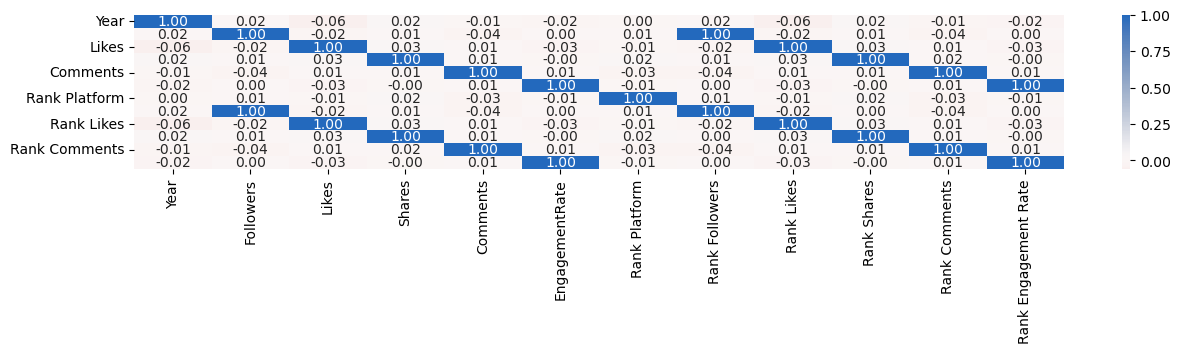

In [269]:
plt.figure(figsize = [15, 2])

sb.heatmap(df_rank.corr(), annot = True, fmt = '.2f', cmap = 'vlag_r', center = 0);

In [270]:
rank_number_details = ['Rank Followers', 'Rank Likes', 'Rank Shares', 'Rank Comments', 'Rank Engagement Rate']

In [271]:
segment_hs_code_description = pd.pivot_table(df_rank, values=rank_number_details, index='Platform',
                          aggfunc=sum)

segment_hs_code_description = segment_hs_code_description.sort_values(by='Rank Followers', ascending=False)
segment_hs_code_description.style.background_gradient(cmap="cubehelix")

,Rank Comments,Rank Engagement Rate,Rank Followers,Rank Likes,Rank Shares
Platform,,,,,
Instagram,240211.000000,235689.500000,245875.500000,235430.500000,234669.000000
Twitter,234582.500000,241249.000000,239893.000000,240569.500000,247000.000000
Facebook,245806.500000,243661.500000,234831.500000,244600.000000,238931.000000


In [272]:
segment_hs_code_description = pd.pivot_table(df_rank, values=rank_number_details, index='Platform',
                          aggfunc=max)

segment_hs_code_description = segment_hs_code_description.sort_values(by='Rank Followers', ascending=False)
segment_hs_code_description.style.background_gradient(cmap="cubehelix")

,Rank Comments,Rank Engagement Rate,Rank Followers,Rank Likes,Rank Shares
Platform,,,,,
Facebook,1182.000000,1186.500000,1200.000000,1196.000000,1193.500000
Twitter,1182.000000,1186.500000,1199.000000,1199.000000,1193.500000
Instagram,1182.000000,1186.500000,1197.500000,1199.000000,1193.500000


In [273]:
segment_hs_code_description = pd.pivot_table(df_rank, values=rank_number_details, index='Platform',
                          aggfunc=min)

segment_hs_code_description = segment_hs_code_description.sort_values(by='Rank Followers', ascending=False)
segment_hs_code_description.style.background_gradient(cmap="cubehelix")

,Rank Comments,Rank Engagement Rate,Rank Followers,Rank Likes,Rank Shares
Platform,,,,,
Instagram,9.000000,19.000000,8.000000,6.000000,8.500000
Twitter,9.000000,19.000000,3.000000,2.500000,8.500000
Facebook,9.000000,19.000000,1.000000,2.500000,8.500000


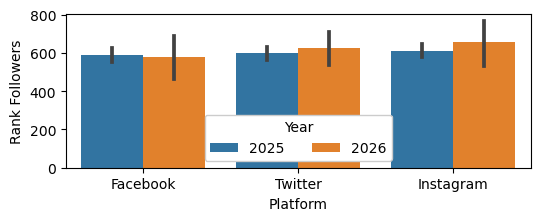

In [274]:
plt.figure(figsize = [6, 2])

ax = sb.barplot(data = df_rank, x = 'Platform', y = 'Rank Followers', hue = 'Year');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Year');

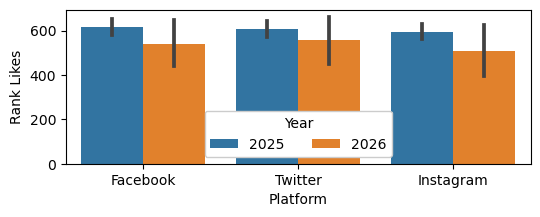

In [275]:
plt.figure(figsize = [6, 2])

ax = sb.barplot(data = df_rank, x = 'Platform', y = 'Rank Likes', hue = 'Year');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Year');

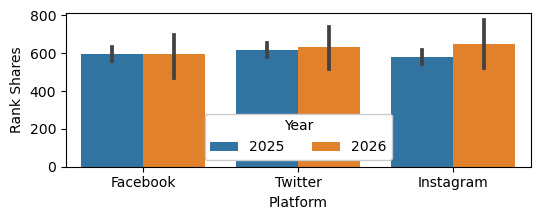

In [276]:
plt.figure(figsize = [6, 2])

ax = sb.barplot(data = df_rank, x = 'Platform', y = 'Rank Shares', hue = 'Year');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Year');

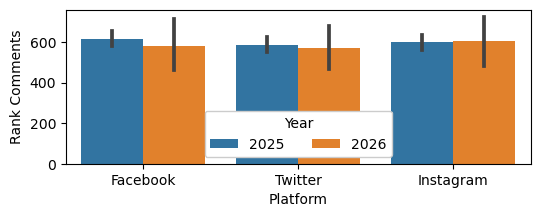

In [277]:
plt.figure(figsize = [6, 2])

ax = sb.barplot(data = df_rank, x = 'Platform', y = 'Rank Comments', hue = 'Year');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Year');

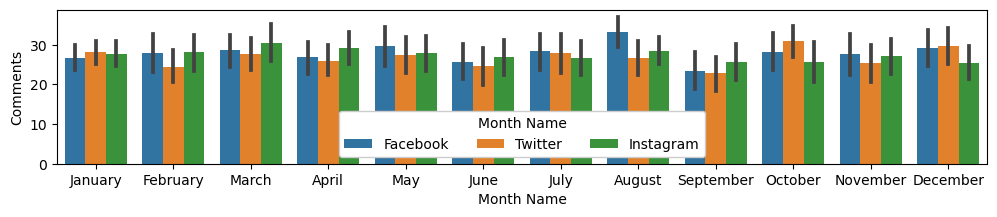

In [278]:
plt.figure(figsize = [12, 2])

ax = sb.barplot(data = df, x = 'Month Name', y = 'Comments', hue = 'Platform');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Month Name');

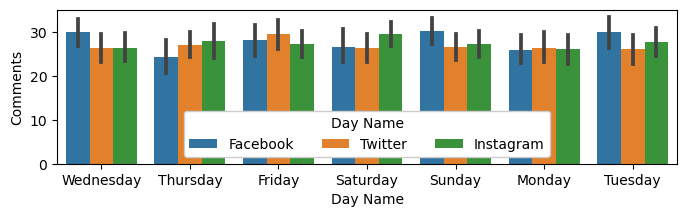

In [279]:
plt.figure(figsize = [8, 2])

ax = sb.barplot(data = df, x = 'Day Name', y = 'Comments', hue = 'Platform');
ax.legend(loc = 8, ncol = 3, framealpha = 1, title = 'Day Name');

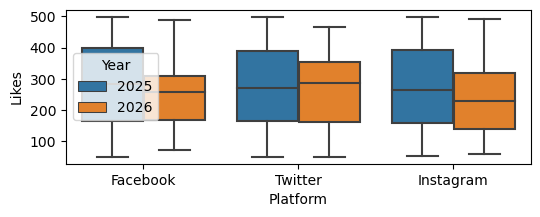

In [280]:
plt.figure(figsize = [6, 2])
sb.boxplot(x='Platform', y='Likes', hue="Year", data=df);

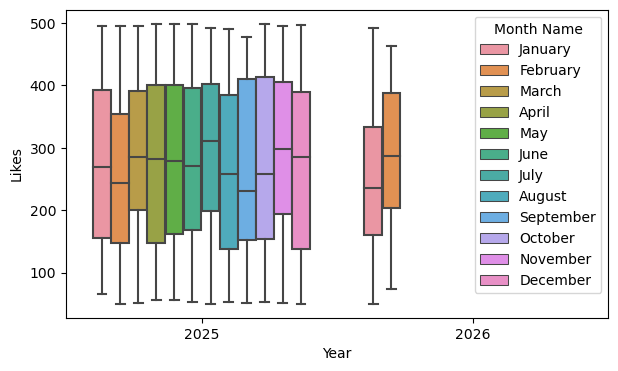

In [281]:
plt.figure(figsize = [7, 4])
sb.boxplot(x='Year', y='Likes', hue="Month Name", data=df);

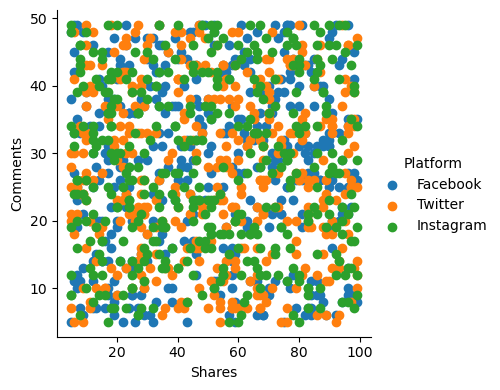

In [282]:
sb.FacetGrid(df, hue='Platform', height=4).map(plt.scatter, "Shares", "Comments").add_legend();

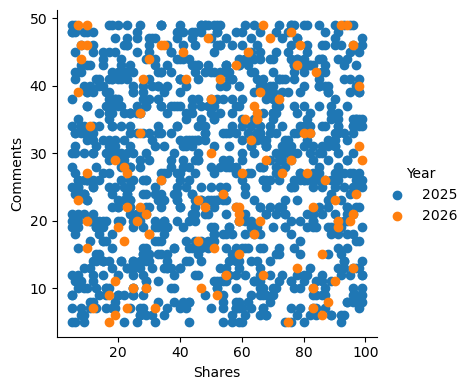

In [283]:
sb.FacetGrid(df, hue='Year', height=4).map(plt.scatter, "Shares", "Comments").add_legend();